# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings. 

Threshold 0
Average: 80.65
Std Dev: 9.093648577135827
Win Prob: 0.01
Loss Prob: 0.99


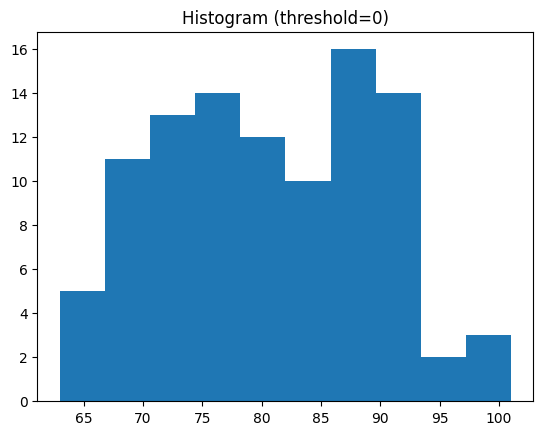

Threshold -2
Average: 83.69
Std Dev: 8.892960557359258
Win Prob: 0.0
Loss Prob: 1.0


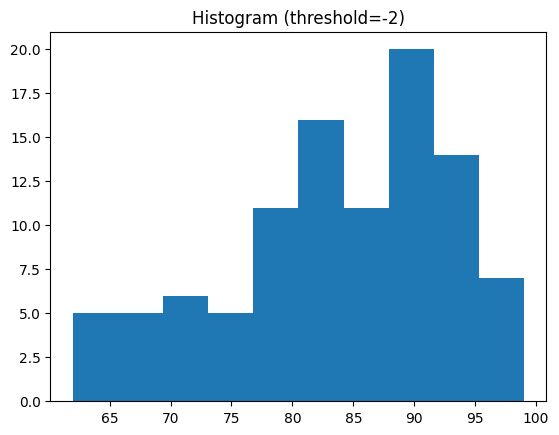

Threshold -1
Average: 80.52
Std Dev: 10.421888388183667
Win Prob: 0.03
Loss Prob: 0.97


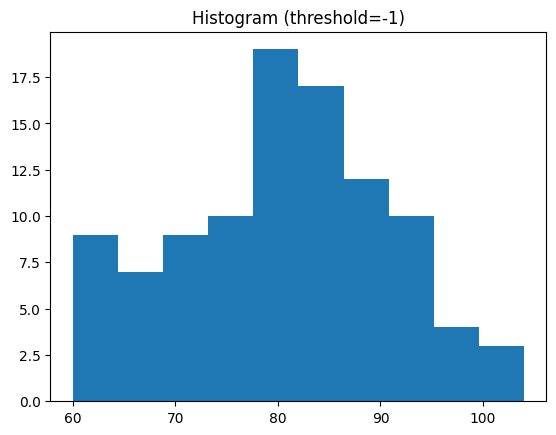

Threshold 0
Average: 81.47
Std Dev: 9.059238267083938
Win Prob: 0.0
Loss Prob: 1.0


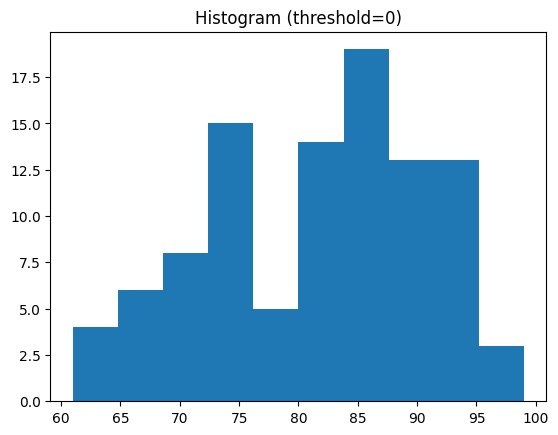

Threshold 1
Average: 77.19
Std Dev: 9.51096655700591
Win Prob: 0.0
Loss Prob: 1.0


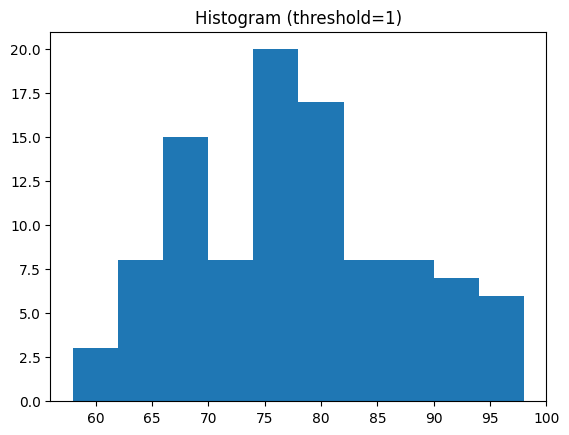

Threshold 2
Average: 77.85
Std Dev: 9.809678790857424
Win Prob: 0.0
Loss Prob: 0.99


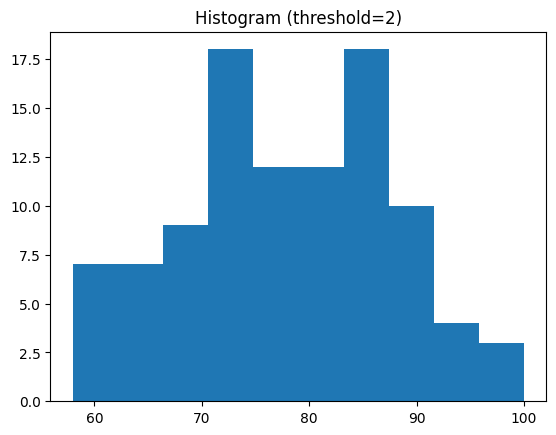

Best threshold: -2
New strategy avg: 95.84


In [1]:
import random
import statistics
import matplotlib.pyplot as plt

# card
class Card:
    def __init__(self, rank):
        self.rank = rank

    def value(self):
        if self.rank in ["J", "Q", "K"]:
            return 10
        elif self.rank == "A":
            return 11
        else:
            return int(self.rank)

    def __str__(self):
        return str(self.rank)


# shoe with multiple decks
class Shoe:
    def __init__(self, num_decks=6):
        self.num_decks = num_decks
        self.cards = []
        self.build_shoe()

    def build_shoe(self):
        ranks = ['2','3','4','5','6','7','8','9','10','J','Q','K','A']
        self.cards = []
        for _ in range(self.num_decks):
            for r in ranks:
                for _ in range(4):
                    self.cards.append(Card(r))

        random.shuffle(self.cards)

        # plastic card
        self.cut_index = random.randint(int(len(self.cards)*0.6), int(len(self.cards)*0.8))

    def draw(self):
        if len(self.cards) == 0:
            self.build_shoe()

        card = self.cards.pop(0)
        return card

    def need_shuffle(self):
        return len(self.cards) < self.cut_index


# hand
class Hand:
    def __init__(self):
        self.cards = []

    def add(self, card):
        self.cards.append(card)

    def value(self):
        total = 0
        aces = 0

        for c in self.cards:
            total += c.value()
            if c.rank == "A":
                aces += 1

        while total > 21 and aces > 0:
            total -= 10
            aces -= 1

        return total

    def is_bust(self):
        return self.value() > 21


# player
class Player:
    def __init__(self, chips=100):
        self.hand = Hand()
        self.chips = chips
        self.bet = 1

    def reset(self):
        self.hand = Hand()

    def place_bet(self):
        self.bet = 1
        self.chips -= self.bet

    def play(self, shoe):
        
        while self.hand.value() < 16:
            self.hand.add(shoe.draw())


# dealer
class Dealer(Player):
    def play(self, shoe):
        while self.hand.value() < 17:
            self.hand.add(shoe.draw())


# count player
class CountPlayer(Player):
    def __init__(self, threshold=0, chips=100):
        super().__init__(chips)
        self.count = 0
        self.threshold = threshold

    def update_count(self, card):
        if card.rank in ['2','3','4','5','6']:
            self.count += 1
        elif card.rank in ['10','J','Q','K','A']:
            self.count -= 1

    def play(self, shoe):
        while True:
            if self.hand.value() >= 21:
                break

            if self.count >= self.threshold:
                break
            else:
                card = shoe.draw()
                self.hand.add(card)
                self.update_count(card)



class BasicStrategyPlayer(Player):
    def play(self, shoe):
        # slightly different: hit until 14
        while self.hand.value() < 14:
            self.hand.add(shoe.draw())


# game
class BlackjackGame:
    def __init__(self, players):
        self.shoe = Shoe()
        self.players = players
        self.dealer = Dealer()

    def deal_initial(self):
        for _ in range(2):
            for p in self.players:
                card = self.shoe.draw()
                p.hand.add(card)
                if isinstance(p, CountPlayer):
                    p.update_count(card)

            card = self.shoe.draw()
            self.dealer.hand.add(card)

    def resolve(self):
        dealer_val = self.dealer.hand.value()

        for p in self.players:
            player_val = p.hand.value()

            if p.hand.is_bust():
                continue
            elif self.dealer.hand.is_bust() or player_val > dealer_val:
                p.chips += 2 * p.bet
            elif player_val == dealer_val:
                p.chips += p.bet

    def play_round(self):
        for p in self.players:
            p.reset()
            p.place_bet()

        self.dealer.reset()

        if self.shoe.need_shuffle():
            self.shoe.build_shoe()

        self.deal_initial()

        for p in self.players:
            p.play(self.shoe)

        self.dealer.play(self.shoe)

        self.resolve()


# simulation
def run_single_game(threshold=0):
    count_player = CountPlayer(threshold=threshold)
    others = [Player() for _ in range(3)]

    players = [count_player] + others
    game = BlackjackGame(players)

    for _ in range(50):
        game.play_round()

    return count_player.chips


def run_experiment(threshold=0):
    results = []

    for _ in range(100):
        res = run_single_game(threshold)
        results.append(res)

    avg = statistics.mean(results)
    std = statistics.stdev(results)

    wins = sum(1 for r in results if r > 100) / len(results)
    losses = sum(1 for r in results if r < 100) / len(results)

    print(f"Threshold {threshold}")
    print("Average:", avg)
    print("Std Dev:", std)
    print("Win Prob:", wins)
    print("Loss Prob:", losses)

    plt.hist(results)
    plt.title(f"Histogram (threshold={threshold})")
    plt.show()

    return avg


# threshold scan
def scan_thresholds():
    thresholds = [-2, -1, 0, 1, 2]
    best = None
    best_val = -999

    for t in thresholds:
        avg = run_experiment(t)
        if avg > best_val:
            best_val = avg
            best = t

    print("Best threshold:", best)


# Q10
def compare_new_strategy():
    results = []

    for _ in range(100):
        p = BasicStrategyPlayer()
        others = [Player() for _ in range(3)]
        game = BlackjackGame([p] + others)

        for _ in range(50):
            game.play_round()

        results.append(p.chips)

    print("New strategy avg:", statistics.mean(results))



if __name__ == "__main__":
    run_experiment(0)
    scan_thresholds()
    compare_new_strategy()